In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_curve, auc
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [12]:
df = pd.read_csv('oasis_cross-sectional.csv')
features = ['Sex', 'Age', 'Educ', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']
X = df[features].copy()
if X['Sex'].dtype == object:
    X['Sex'] = X['Sex'].astype(str).str.strip().str.upper().map({'M': 0, 'F': 1})
y = df['CDR'].apply(lambda x: 1 if x >= 0.5 else 0)
imputer = SimpleImputer(strategy='median')
X_prep = imputer.fit_transform(X)

In [13]:
def evaluar_modelo_roc(nombre, creador_modelo, X_data, y_target, color, escalar=False):
    mean_fpr = np.linspace(0, 1, 100)
    tprs = []
    aucs = []
    fig, ax = plt.subplots(figsize=(8, 6))
    print(f"\nProcesando 10 iteraciones para: {nombre}")

    for i in range(10):
        X_train, X_test, y_train, y_test = train_test_split(
            X_data,
            y_target,
            test_size=0.20,
            random_state=i,
            stratify=y_target,
        )

        if escalar:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

        modelo = creador_modelo()
        modelo.fit(X_train, y_train)
        y_proba = modelo.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)

        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        aucs.append(roc_auc)
        ax.plot(fpr, tpr, lw=1, alpha=0.25)

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = np.std(aucs)

    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.6, label='Azar')
    ax.plot(
        mean_fpr,
        mean_tpr,
        color=color,
        lw=3,
        label=f'Promedio (AUC = {mean_auc:.3f} ± {std_auc:.2f})',
    )
    ax.set_title(f'Curvas ROC - {nombre} (10 iteraciones 80-20)')
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return mean_fpr, mean_tpr, mean_auc


Procesando 10 iteraciones para: Árbol de decisión


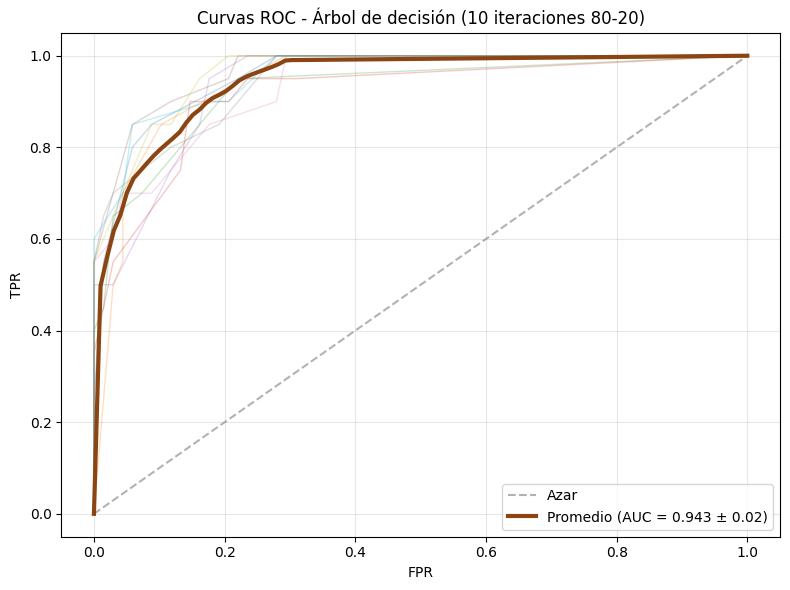


Procesando 10 iteraciones para: KNN


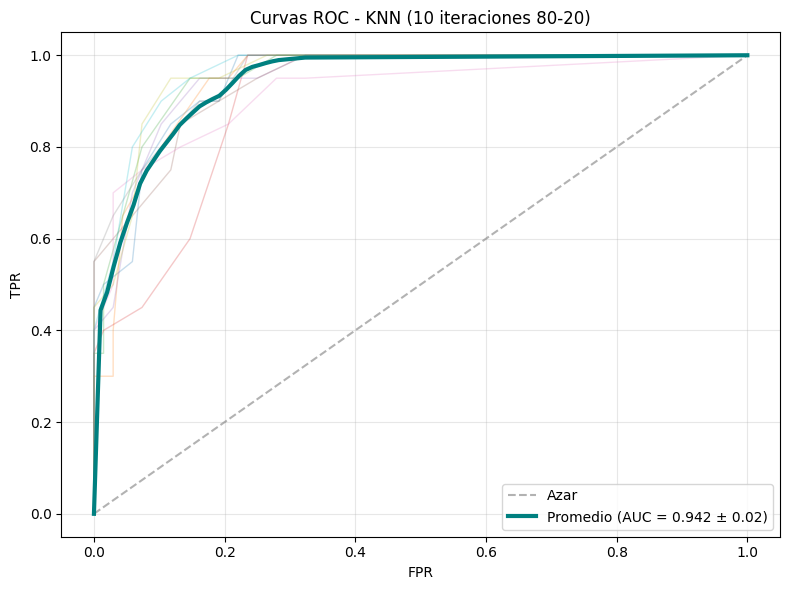


Procesando 10 iteraciones para: Naive Bayes(Gaussian)


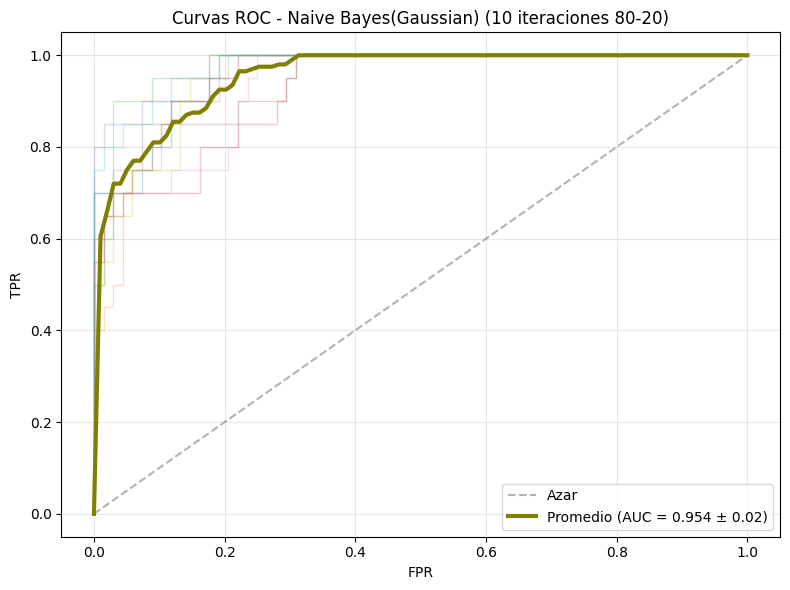


Procesando 10 iteraciones para: Naive Bayes(Multinomial)


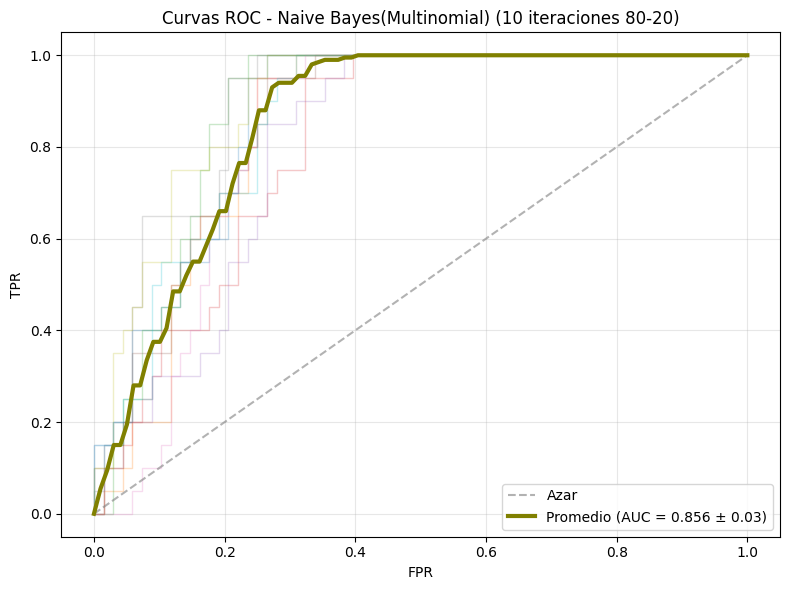


Procesando 10 iteraciones para: Random Forest


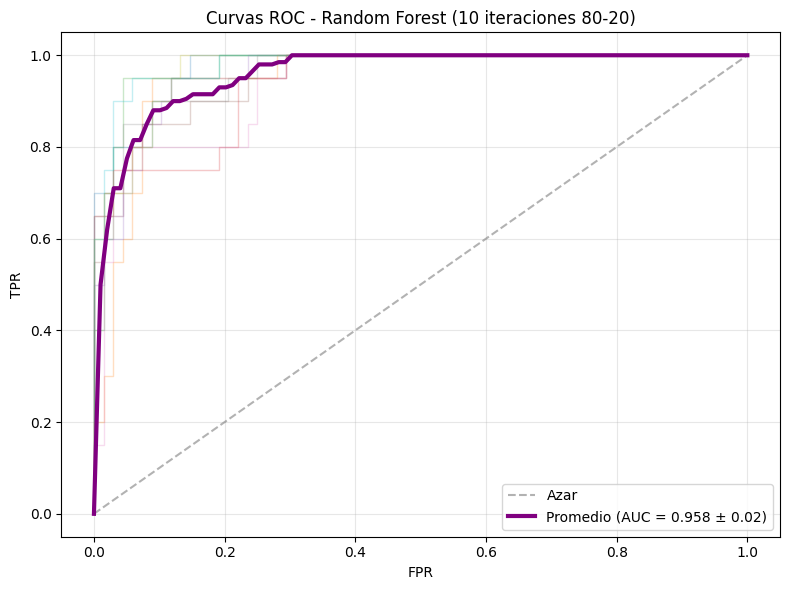


Procesando 10 iteraciones para: Reg. Logística


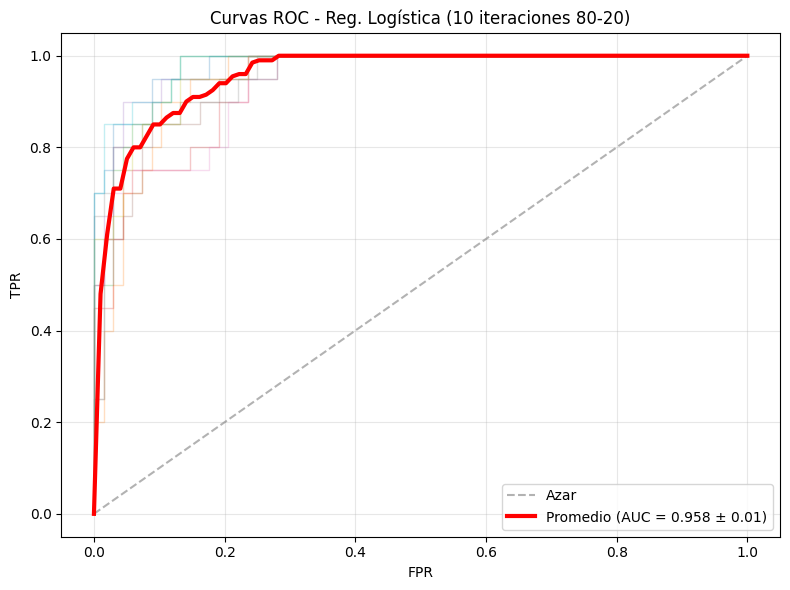


Procesando 10 iteraciones para: SVM


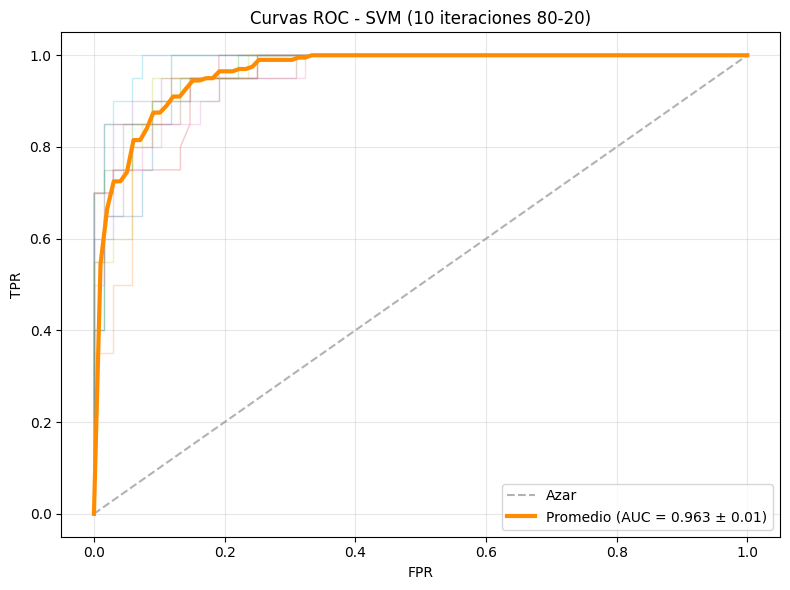


Procesando 10 iteraciones para: XGBoost


/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [02:48:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [02:48:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [02:48:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-d

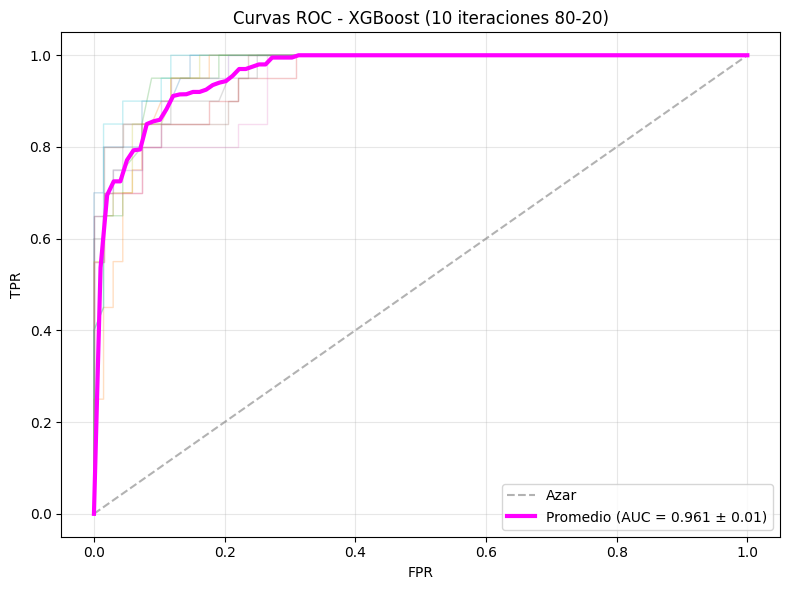

In [14]:
from sklearn.naive_bayes import MultinomialNB


modelos_dict = {
    'Árbol de decisión': (
        lambda: DecisionTreeClassifier(max_depth=4, min_samples_leaf=14, random_state=42),
        'saddlebrown',
        False,
    ),
    'KNN': (
        lambda: KNeighborsClassifier(n_neighbors=11),
        'teal',
        True,
    ),
    'Naive Bayes(Gaussian)': (
        lambda: GaussianNB(),
        'olive',
        False,
    ),
    'Naive Bayes(Multinomial)': (
        lambda: MultinomialNB(),
        'olive',
        False,
    ),
    'Random Forest': (
        lambda: RandomForestClassifier(n_estimators=100, max_depth=9, min_samples_leaf=4, random_state=42),
        'purple',
        False,
    ),
    'Reg. Logística': (
        lambda: LogisticRegression(C=0.1, max_iter=1000, random_state=42),
        'red',
        True,
    ),
    'SVM': (
        lambda: SVC(kernel='rbf',
            C=300,
            gamma=0.01,
            probability=True,
            class_weight='balanced',
            random_state=42),
        'darkorange',
        True,
    ),
    'XGBoost': (
        lambda: XGBClassifier(n_estimators=50,
        max_depth=1,
        learning_rate=0.2,
        subsample=0.9,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'),
        'magenta',
        False,
    ),
}

resultados_finales = {}
for nombre, (creador_modelo, color, escalar) in modelos_dict.items():
    fpr_v, tpr_v, auc_v = evaluar_modelo_roc(nombre, creador_modelo, X_prep, y, color, escalar=escalar)
    resultados_finales[nombre] = (fpr_v, tpr_v, auc_v, color)


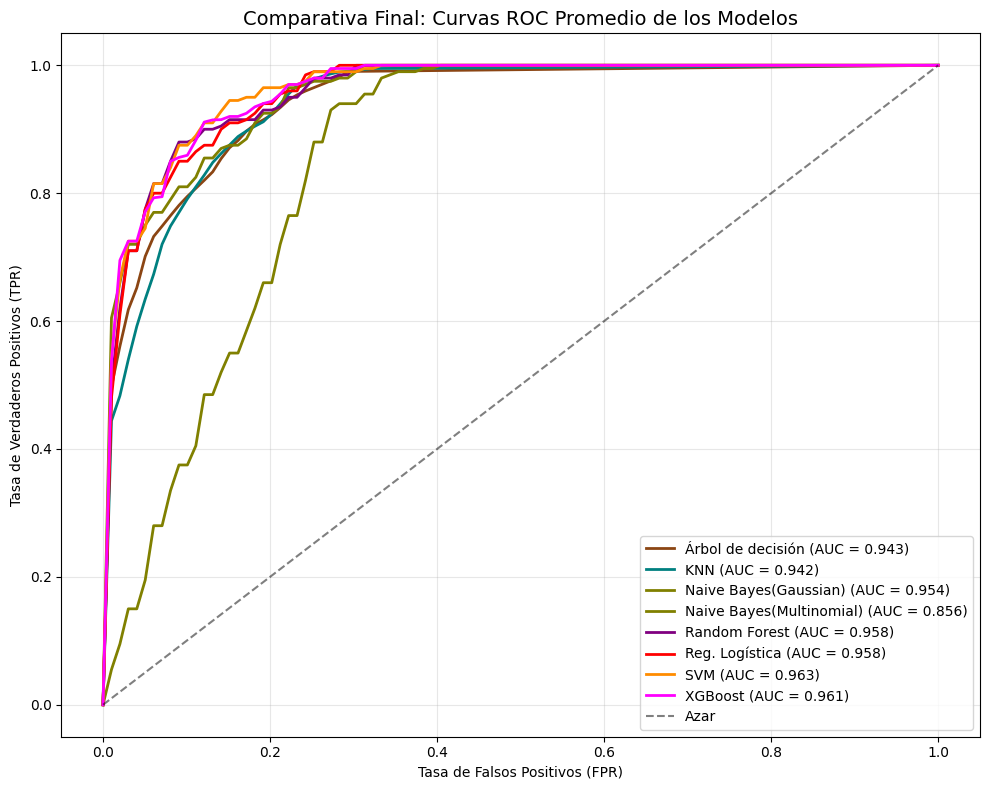

In [15]:
plt.figure(figsize=(10, 8))
for nombre, (fpr, tpr, auc_v, color) in resultados_finales.items():
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{nombre} (AUC = {auc_v:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.5, label='Azar')
plt.title('Comparativa Final: Curvas ROC Promedio de los Modelos', fontsize=14)
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()